# **Bibliotecas**

In [7]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# **Extract data base**

In [8]:
archivo = requests.get('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')
archivo_texto = archivo.json()

In [9]:
pd.json_normalize (archivo_texto, sep= '_')

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [10]:
data = pd.json_normalize (archivo_texto, sep= '_')

In [11]:
columnas = data.columns.tolist()

# **Transform data base**

## *Datos nulos*

In [12]:
for col in columnas:
    print (f'{col}: {data[col].isna().sum()} datos nulos')

customerID: 0 datos nulos
Churn: 0 datos nulos
customer_gender: 0 datos nulos
customer_SeniorCitizen: 0 datos nulos
customer_Partner: 0 datos nulos
customer_Dependents: 0 datos nulos
customer_tenure: 0 datos nulos
phone_PhoneService: 0 datos nulos
phone_MultipleLines: 0 datos nulos
internet_InternetService: 0 datos nulos
internet_OnlineSecurity: 0 datos nulos
internet_OnlineBackup: 0 datos nulos
internet_DeviceProtection: 0 datos nulos
internet_TechSupport: 0 datos nulos
internet_StreamingTV: 0 datos nulos
internet_StreamingMovies: 0 datos nulos
account_Contract: 0 datos nulos
account_PaperlessBilling: 0 datos nulos
account_PaymentMethod: 0 datos nulos
account_Charges_Monthly: 0 datos nulos
account_Charges_Total: 0 datos nulos


## *Duplicados*

In [13]:
print(f"Datos duplicados (filas): {data.duplicated().sum()}")
data = data.drop_duplicates()

Datos duplicados (filas): 0


In [14]:
for unicos in columnas:
    print (f'{unicos}: {data[unicos].unique()} valores únicos')

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] valores únicos
Churn: ['No' 'Yes' ''] valores únicos
customer_gender: ['Female' 'Male'] valores únicos
customer_SeniorCitizen: [0 1] valores únicos
customer_Partner: ['Yes' 'No'] valores únicos
customer_Dependents: ['Yes' 'No'] valores únicos
customer_tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0] valores únicos
phone_PhoneService: ['Yes' 'No'] valores únicos
phone_MultipleLines: ['No' 'Yes' 'No phone service'] valores únicos
internet_InternetService: ['DSL' 'Fiber optic' 'No'] valores únicos
internet_OnlineSecurity: ['No' 'Yes' 'No internet service'] valores únicos
internet_OnlineBackup: ['Yes' 'No' 'No internet service'] valores únicos
internet_DeviceProtection: ['No' 'Yes' 'No internet service'] valores ún

## *Tipo de datos*

In [15]:
data.sample(3)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
1760,2504-DSHIH,No,Male,1,Yes,No,23,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,No,Electronic check,86.80,1975.85
3330,4634-JLRJT,No,Female,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.35,20.35
3835,5244-IRFIH,Yes,Male,1,Yes,No,33,Yes,Yes,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,3105.55


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

*La columna de carga total (columna final) es de tipo float y el tipo actual es object.*
*Además, hay algunas columnas donde cada celda contiene elementos con espacios en blanco ' ' que puedan estropear el análisis y aumentar el error estándar de estimación*

- **se realizará una limpieza genérica**

In [17]:
data = data.replace (' ', np.nan)

In [18]:
data['account_Charges_Total'] = data['account_Charges_Total'].astype(np.float64)

In [19]:
for col in data.select_dtypes (include= 'object').columns:
    data[col] = data[col].str.strip().replace ('', np.nan)

print (data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [20]:
for col in columnas:
    print (data[col].isna().sum())

0
224
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
11


In [21]:
data = data.dropna()
print (data['Churn'].isna().sum())

0


## *Inconsistencias y manipulación de strings*

In [23]:
data.columns = data.columns.str.lower()
print (data.columns)

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')


*Por ej:*
- Me gustaría crear una nueva columna indicando si al acceder a esta página el usuario quería comprar algo. Es decir, ¿la URI comienza con /compra/? Si es,True, si no False. Para esto tenemos la función startswith:

datos['comprando'] = datos.uri.str.startswith("/compra") aun que es mejor con .str.contains porque quizá está el parámetro "/compra" pero no al principio, quizá en medio.

- La serie creada (columna) tendrá dos parámetros booleanos, verdadero o falso, por lo que para verificar como quedaron algunos utilizamos:

datos.query("comprando==True").head()

% de compras?, con: datos.comprando.value_counts()

In [26]:
columnas = data.columns.tolist()

In [27]:
for unicos in columnas:
    print (f'{unicos}: {data[unicos].unique()} valores únicos')

customerid: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] valores únicos
churn: ['No' 'Yes'] valores únicos
customer_gender: ['Female' 'Male'] valores únicos
customer_seniorcitizen: [0 1] valores únicos
customer_partner: ['Yes' 'No'] valores únicos
customer_dependents: ['Yes' 'No'] valores únicos
customer_tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42] valores únicos
phone_phoneservice: ['Yes' 'No'] valores únicos
phone_multiplelines: ['No' 'Yes' 'No phone service'] valores únicos
internet_internetservice: ['DSL' 'Fiber optic' 'No'] valores únicos
internet_onlinesecurity: ['No' 'Yes' 'No internet service'] valores únicos
internet_onlinebackup: ['Yes' 'No' 'No internet service'] valores únicos
internet_deviceprotection: ['No' 'Yes' 'No internet service'] valores únicos
in

In [30]:
data['account_charges_day'] = (data['account_charges_monthly'] / 30).fillna(0)

## *Estandarización*

In [35]:
for col in data.select_dtypes (include= 'object').columns:
    data[col] = data[col].replace ({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'No internet service': 0, 'No phone service': 0}).infer_objects(copy= False)

for col in data.select_dtypes(include='bool').columns:
    data[col] = data[col].astype(int)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7032 non-null   object 
 1   churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   int64  
 3   customer_seniorcitizen     7032 non-null   int64  
 4   customer_partner           7032 non-null   int64  
 5   customer_dependents        7032 non-null   int64  
 6   customer_tenure            7032 non-null   int64  
 7   phone_phoneservice         7032 non-null   int64  
 8   phone_multiplelines        7032 non-null   int64  
 9   internet_internetservice   7032 non-null   object 
 10  internet_onlinesecurity    7032 non-null   int64  
 11  internet_onlinebackup      7032 non-null   int64  
 12  internet_deviceprotection  7032 non-null   int64  
 13  internet_techsupport       7032 non-null   int64  
 1

In [37]:
for col in columnas:
    print (f'{col}: {data[col].unique()}')

customerid: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
churn: [0 1]
customer_gender: [0 1]
customer_seniorcitizen: [0 1]
customer_partner: [1 0]
customer_dependents: [1 0]
customer_tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
phone_phoneservice: [1 0]
phone_multiplelines: [0 1]
internet_internetservice: ['DSL' 'Fiber optic' 0]
internet_onlinesecurity: [0 1]
internet_onlinebackup: [1 0]
internet_deviceprotection: [0 1]
internet_techsupport: [1 0]
internet_streamingtv: [1 0]
internet_streamingmovies: [0 1]
account_contract: ['One year' 'Month-to-month' 'Two year']
account_paperlessbilling: [1 0]
account_paymentmethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
account_charges_monthly: [65.6  59.9  73.9  ... 91.75 68.8  

# **Análisis**

## *Estadística descriptiva*

In [96]:
descriptivos = data.describe()
descriptivos = descriptivos.style.format ('{:.2f}')
descriptivos.set_sticky(axis= 'index')

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_paperlessbilling,account_charges_monthly,account_charges_total,account_charges_day
count,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00
mean,0.27,0.50,0.16,0.48,0.30,32.42,0.90,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.80,2283.30,2.16
std,0.44,0.50,0.37,0.50,0.46,24.55,0.30,0.49,0.45,0.48,0.48,0.45,0.49,0.49,0.49,30.09,2266.77,1.00
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.61
25%,0.00,0.00,0.00,0.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.59,401.45,1.19
50%,0.00,1.00,0.00,0.00,0.00,29.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.35,1397.47,2.34
75%,1.00,1.00,0.00,1.00,1.00,55.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.86,3794.74,3.00
max,1.00,1.00,1.00,1.00,1.00,72.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,3.96


*¿Cuántas personas dejó o no a la empresa?*

- El 26,6% de los clientes abandonaron el servicio, o sea una cuarta parte del total de clientes prácticamente.

In [97]:
data['churn'].value_counts(normalize= True)

churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [98]:
print (data['internet_internetservice'].value_counts(normalize= True))


internet_internetservice
Fiber optic    0.440273
DSL            0.343572
0              0.216155
Name: proportion, dtype: float64


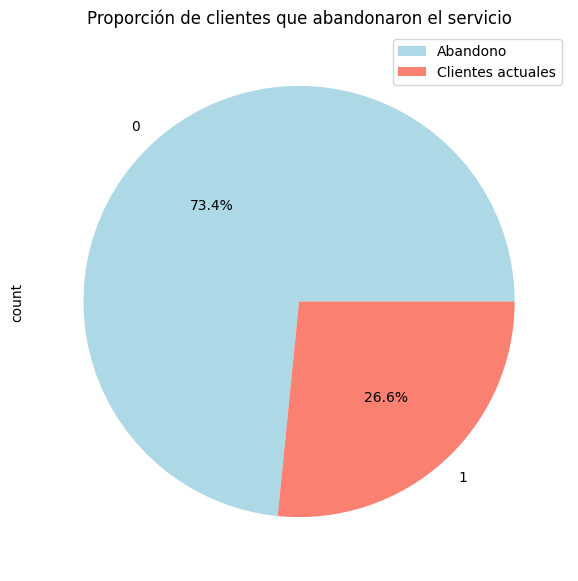

In [99]:
data['churn'].value_counts().plot(kind= 'pie', autopct= '%1.1f%%', colors=['lightblue', 'salmon'], figsize= (7,7))
plt.title ('Proporción de clientes que abandonaron el servicio')
plt.legend (labels= ['Abandono', 'Clientes actuales'])
plt.show()

In [100]:
df_evasion = data.query ('churn == 1').copy()

## *Análisis estadístico inferencial*

**¿Si la inferencia estadística sirve para extrapolar datos con una muestra, por que se utiliza en un dataframe con los datos de TODOS los clientes?**

- *Porque además de tomar una muestra para analizarla y luego los resultados extrapolarlos a una población mayor, también sirve para confirmar hallazgos, sirve para confirmar si las diferencias observadas son significativas (no son al azar), para validar estadísticamente las decisiones, para saber si es importante o no lo que uno está analizando y además para saber qué tan importante es o no el hallazgo, lo que facilita la toma de decisiones estratégica de negocios*

*Distribución de los datos*:

Antes de hacer cualquier test de hipótesis, hay que saber primero cuál es la distribución de los datos por dos cosas generales:

- Los test son distintos si los datos son paramétricos o no paramétricos (distribución normal o no)
- Las distribuciones no paramétricas generalmente se hacen utilizando la mediana y no los promedios (medias), porque soportan más los outliers (valores atípicos)

*El test a utilizar para verificar si los datos siguen una distribución normal o no es el test de Shapiro Wilk*
H0: Distribución paramétrica (normal)
H1: Distribución no paramétrica (no es normal)

> - Valor P (p-value), SIEMPRE: si es menor a 0.05, se rechaza H0 (o sea, básicamente es como si no se tomara en cuenta), por ende uno se "queda" con H1.
> - En caso que sea MAYOR a 0.05, entonces se dice que NO SE RECHAZA (nunca se dice: me quedo con H1, porque existe una probabilidad que ocurra una u otra, pero una es mas probable que la otra), por ende en este último caso uno se "queda" con H1.
> - p-value demuestra la significancia, o que tanto importa el resultado que uno esté realizando por decirlo de alguna forma, generalmente estos test trabajan con 95% de confianza, o sea el restante es el error que puede ocurrir.
> - SIGNIFICANCIA ≠ CONFIANZA (X cosa es significativa? si o no?, bueno, en caso que sí... qué tanto confío en esta importancia?, generalmente en los test es un 95%... --Hay métodos para calcular con una confianza más alta o más baja--)

> - Relación no significa causalidad... por ejemplo uno podría ver que la tendencia que aumenten las ventas sea positiva y también que justamente aumentaron los clientes, pero no significa que por esta razón hayan aumentando las ventas... ¿por qué?, porque se habla de relación, no de causalidad; Por ejemplo podríamos decir que en verano, disminuye la cantidad de accidentes y JUSTAMENTE también disminuye la cantidad de días que llueve mensualmente, eso es una relación, correlación o covarianza, pero no tienen nada que ver, es decir, una no causa a la otra y es por esto que los test se hacen con variables INDEPENDIENTES generalmente.


## *Los cargos mensuales son diferentes entre quienes abandonan vs quienes no?*

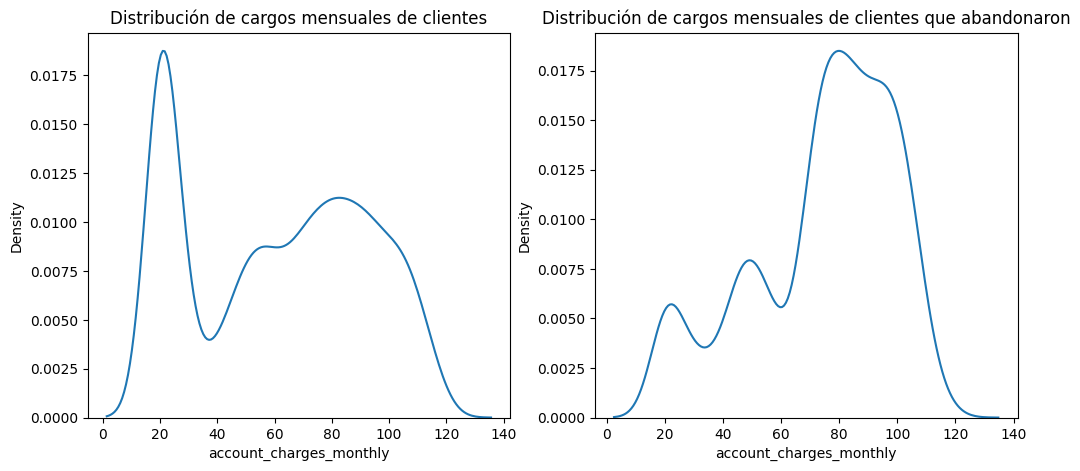

Estadístico: 0.9129816238871855, p-value: 1.850616771649478e-47

Estadístico: 0.9284018013401676, p-value: 5.363083193565018e-29


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5163.
  res = hypotest_fun_out(*samples, **kwds)


In [101]:
from scipy.stats import shapiro

fig, axs =plt.subplots (1,2, figsize= (12,5))

sns.kdeplot (data= data.query('churn == 0')['account_charges_monthly'], ax= axs[0])
axs[0].set_title ('Distribución de cargos mensuales de clientes')

sns.kdeplot (data= data.query('churn == 1')['account_charges_monthly'], ax= axs[1])
axs[1].set_title ('Distribución de cargos mensuales de clientes que abandonaron')

plt.show()

est, p_value = shapiro (data.query('churn == 0')['account_charges_monthly']) #est significa valor estadístico
print (f'Estadístico: {est}, p-value: {p_value}')

est, p_value = shapiro (data.query('churn == 1')['account_charges_monthly']) #est significa valor estadístico
print (f'\nEstadístico: {est}, p-value: {p_value}')

*Clientes que NO abandonan (churn = 0):*
- p-value: 1.85e-47 (extremadamente pequeño, << 0.05)
- Conclusión: Se RECHAZA H0, los datos NO siguen distribución normal

*Clientes que SÍ abandonan (churn = 1):*
- p-value: 5.36e-29 (extremadamente pequeño, << 0.05)
- Conclusión: Se RECHAZA H0, los datos NO siguen distribución normal

Cuando no siguen distribución normal se utiliza un test sobre la MEDIANA (no media) de U-Mann Whitney

In [102]:
# Test no paramétrico hipótesis sobre la media (two-sided: probar diferencias, greater: si el primero es mas grande que el segundo --H0: iguales, less: al revés de greater, two-sided: probar diferencias)
#H0: Las medianas de los cargos mensuales de los clientes que abandonaron y los que no, son iguales.
#H1: Las medianas de los cargos mensuales de los clientes que abandonaron y los que no, son diferentes.
from scipy.stats import mannwhitneyu
stat, p_val = mannwhitneyu (data.query('churn == 0')['account_charges_monthly'], \
                            data.query('churn == 1')['account_charges_monthly'], \
                            alternative='two-sided')
print(f"Estadístico U: {stat}")
print(f"P-valor: {p_val}")

Estadístico U: 3663498.5
P-valor: 8.467195044548749e-54


*Medianas diferentes (p-value < 0.05 --O sea, uno se "queda" con H1... para ir explicando de forma más sencilla al principio--)*
- Esto significa que unos pagan más que otros... o los clientes actuales, o los que abandonan...

In [103]:
'''¿Pagarán más los clientes que abandonaron el servicio? (porque less revisa si el segundo parametro
es mayor que el primero'''
from scipy.stats import mannwhitneyu
stat, p_val = mannwhitneyu (data.query('churn == 0')['account_charges_monthly'], \
                            data.query('churn == 1')['account_charges_monthly'], \
                            alternative='less')
print(f"Estadístico U: {stat}")
print(f"P-valor: {p_val}")

Estadístico U: 3663498.5
P-valor: 4.2335975222743747e-54


### **Conclusión 1**

***Los clientes que abandonan el servicio pagan significativamente MÁS que los que se quedan.***

Se rechaza la hipótesis nula (H0) porque p-value < 0.05, es decir los clientes que no abandonan pagan menos que los que sí abandonan.
Esto es un hallazgo muy importante, porque:

- Los cargos altos están asociados con mayor abandono
- Posible insatisfacción con la relación del precio que pagan versus el beneficio que perciben del servicio
- Oportunidad de revisar estrategias de pricing o agregar más valor a planes caros

## *¿La antigüedad influye en que se vayan los clientes o no?*

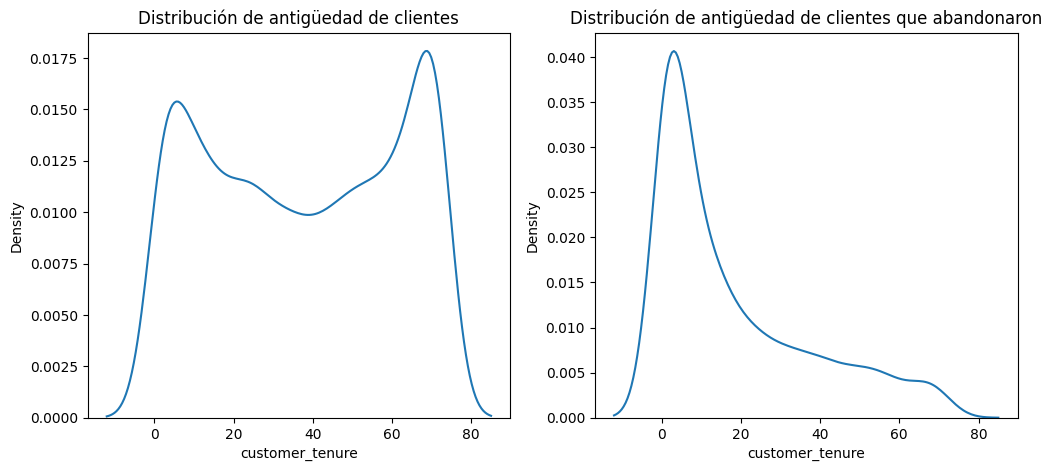

In [108]:
from scipy.stats import shapiro

fig, axs =plt.subplots (1,2, figsize= (12,5))

sns.kdeplot (data= data.query('churn == 0')['customer_tenure'], ax= axs[0])
axs[0].set_title ('Distribución de antigüedad de clientes')

sns.kdeplot (data= data.query('churn == 1')['customer_tenure'], ax= axs[1])
axs[1].set_title ('Distribución de antigüedad de clientes que abandonaron')

plt.show()

*Distribución visualmente no paramétrica*

In [109]:
# Comparar antigüedad entre TODOS los clientes que abandonan vs los que no
est, p_value = mannwhitneyu(data.query('churn == 0')['customer_tenure'], \
                           data.query('churn == 1')['customer_tenure'], \
                           alternative='two-sided')

print(f"Estadístico U: {est}")
print(f"P-valor: {p_value}")

Estadístico U: 7154668.0
P-valor: 6.043046580882717e-211


*Existen diferencias... p-value < 0.05 (se rechaza H0)*

In [110]:
est, p_value = mannwhitneyu(data.query('churn == 0')['customer_tenure'], \
                           data.query('churn == 1')['customer_tenure'], \
                           alternative='greater')

print(f"Estadístico U: {est}")
print(f"P-valor: {p_value}")

Estadístico U: 7154668.0
P-valor: 3.0215232904413584e-211


*Proporción de tipos de contrato*

In [117]:
data.account_contract.value_counts(normalize= True)

account_contract
Month-to-month    0.551052
Two year          0.239619
One year          0.209329
Name: proportion, dtype: float64

### **Conclusión 2**

**Los clientes que abandonan el servicio son significativamente más antiguos que los clientes que aún no abandonan**

- Esto es un hallazgo muy importante, porque se rechaza la hipótesis nula (H0) porque p-value < 0.05, quiere decir que los clientes que no abandonan son más antiguos, es decir, los clientes que abandonan tienden a ser más nuevos con un 95% de confianza.

- Además como se puede visualizar, la mayoría de los contratos (55% aprox) son de pagos mes a mes, lo que no "amarra" al consumidor del servicio para al menos realizar esfuerzos por retenerlo y aumentar el life time value (LTV)

## *Correlaciones*

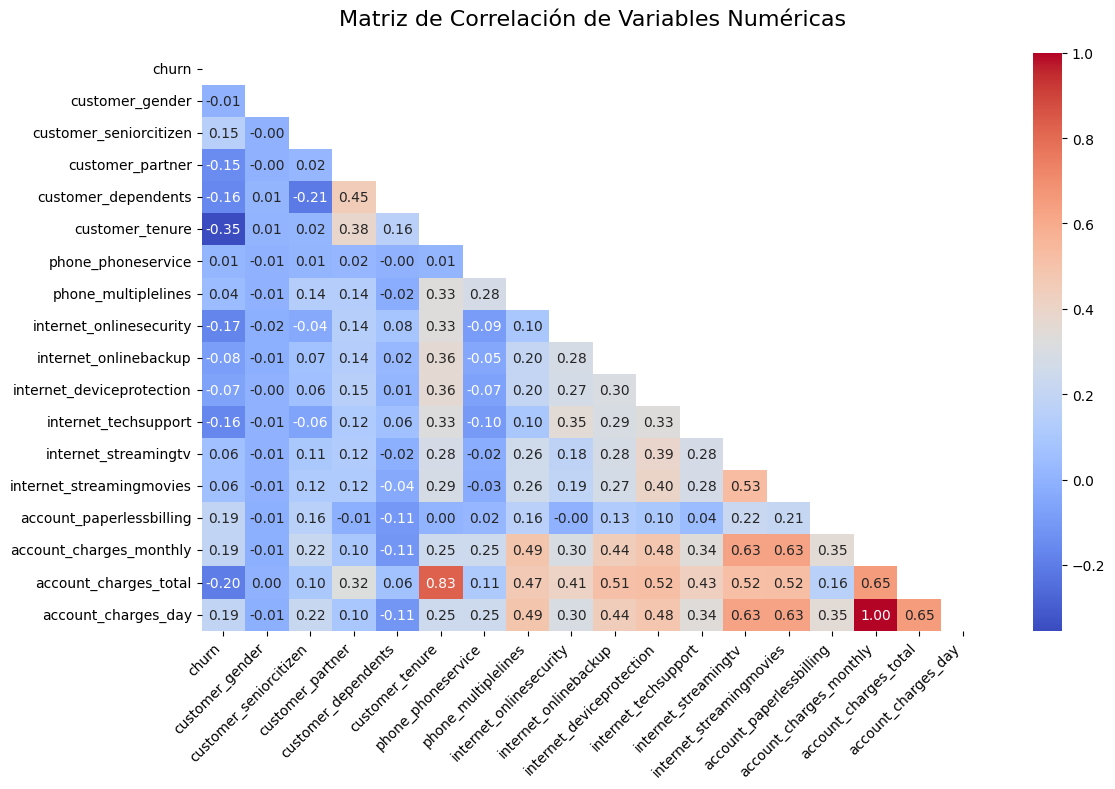

In [135]:
correlacion = data.select_dtypes(include= [np.number]).corr()

mask = np.triu(np.ones_like(correlacion, dtype=bool))
plt.figure (figsize= (12,8))
sns.heatmap (correlacion, mask=mask, annot= True, cmap= 'coolwarm', fmt= '.2f')

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## *¿El tipo de contrato está relacionado con el churn?*

Estadístico Chi-cuadrado: 1179.5458
P-valor: 7.326182186265472e-257
Grados de libertad: 2

Valores esperados:
[[2845.08319113 1029.91680887]
 [1080.76450512  391.23549488]
 [1237.15230375  447.84769625]]

Se RECHAZA H0 (p-value < 0.05)
Conclusión: El tipo de contrato SÍ está significativamente relacionado con el churn


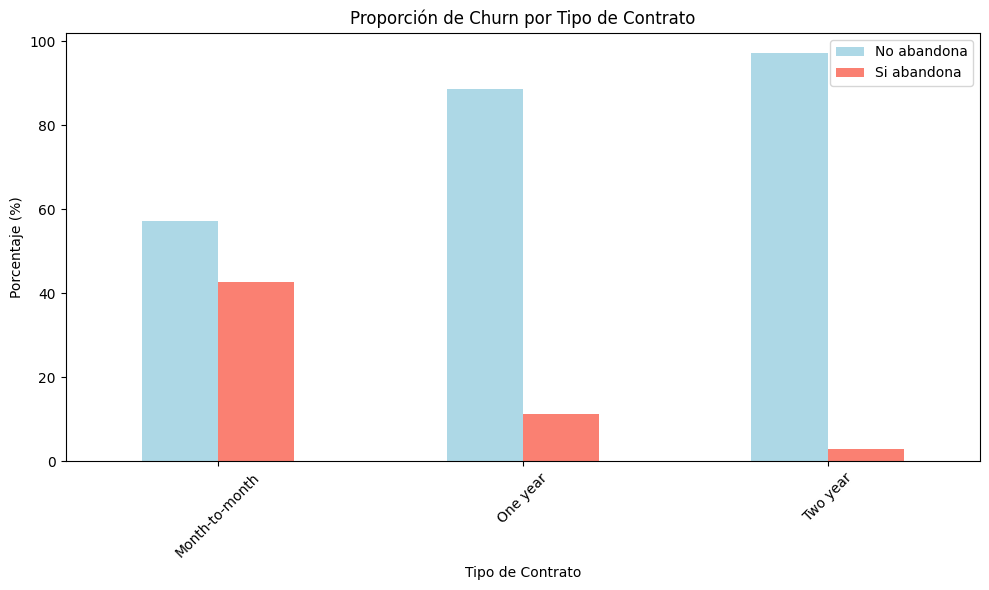

In [153]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla = pd.crosstab(data['account_contract'], data['churn'])

# test Chi-cuadrado
chi2, p_value, gl, expected = chi2_contingency(tabla)

print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
print(f"P-valor: {p_value}")
print(f"Grados de libertad: {gl}")
print(f"\nValores esperados:")
print(expected)

# Interpretación
if p_value < 0.05:
    print(f"\nSe RECHAZA H0 (p-value < 0.05)")
    print("Conclusión: El tipo de contrato SÍ está significativamente relacionado con el churn")
else:
    print(f"\nNO se rechaza H0 (p-value >= 0.05)")
    print("Conclusión: El tipo de contrato NO está significativamente relacionado con el churn")

# Visualización
tabla_prop = pd.crosstab(data['account_contract'], data['churn'], normalize='index') * 100
tabla_prop.plot(kind='bar', figsize=(10, 6), color=['lightblue', 'salmon'])
plt.title('Proporción de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Porcentaje (%)')
plt.legend(['No abandona', 'Si abandona'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [156]:
# Valores exactos
pd.crosstab(data['account_contract'], data['churn'], normalize='index') * 100

churn,0,1
account_contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


### **Conclusión 3**


**El tipo de contrato sí está relacionado con el abandono**

- Esto es un hallazgo muy importante, porque se rechaza la hipótesis nula (H0) porque p-value < 0.05, quiere decir que los tipos de contrato que tienen los clientes sí se relacionan en cuanto al abandono, afirmando esto con un 95% de confianza, de hecho, el 42.7% de los clientes que abandonan no tienen un contrato fijo, sólo pagan mes a mes.

- Además como se puede visualizar, la mayoría de los contratos de los clientes que abandonan (42.7% aprox) son de pagos mes a mes, lo que no "amarra" al consumidor del servicio para al menos realizar esfuerzos por retenerlo y aumentar el life time value (LTV) reafirmando la conclusión 2 anterior.

# **INFORME**

---

## **1. Introducción**

El presente análisis tiene como objetivo identificar los factores que influyen en la **evasión de clientes (Churn)** de la empresa de telecomunicaciones TelecomX. La retención de clientes es un desafío crítico en la industria de telecomunicaciones, donde la competencia es intensa y los costos de adquisición de nuevos clientes son significativamente mayores que los costos de retención.

### **Problema de negocio:**
TelecomX enfrenta una tasa de abandono del **26.6%**, lo que representa aproximadamente una cuarta parte de su base de clientes. Esta cifra es alarmante y requiere una investigación profunda para entender qué variables están asociadas con la decisión de los clientes de abandonar el servicio.

### **Objetivo del análisis:**
- Identificar los principales factores que influyen en el churn
- Analizar diferencias significativas entre clientes que abandonan versus los que permanecen
- Proporcionar recomendaciones estratégicas basadas en datos para reducir la tasa de abandono
- Detectar segmentos de alto riesgo que requieren atención prioritaria

## **2. Limpieza y Tratamiento de Datos**

### **2.1 Extracción de datos**
Los datos fueron obtenidos desde un archivo JSON alojado en GitHub, conteniendo información de clientes de TelecomX con variables demográficas, de servicios contratados y de facturación.

### **2.2 Proceso de limpieza realizado:**

**Normalización de estructura:**
- Se utilizó `pd.json_normalize()` para convertir el JSON anidado en un DataFrame tabular
- Se aplicó separador `_` para aplanar la estructura jerárquica de datos

**Tratamiento de valores nulos:**
- Se identificaron **11 registros** con espacios en blanco (`' '`) que fueron reemplazados por `np.nan`
- Se eliminaron filas con valores nulos, garantizando la calidad del análisis

**Eliminación de duplicados:**
- Se verificó y eliminó cualquier registro duplicado para evitar sesgos en el análisis

**Estandarización de datos:**
- Se convirtieron todos los nombres de columnas a **minúsculas** para consistencia
- Se estandarizaron valores categóricos:
  - `'Yes'/'yes'` → `1`, `'No'/'no'` → `0`
  - `'Male'` → `1`, `'Female'` → `0`
  - `'No internet service'/'No phone service'` → `0`
- Se aplicó `.infer_objects()` para asegurar tipos de datos correctos

**Transformaciones adicionales:**
- Se corrigió el tipo de dato de `account_Charges_Total` de `object` a `float64`
- Se creó la columna calculada `account_charges_day` dividiendo los cargos mensuales entre 30
- Se eliminaron espacios en blanco al inicio y final de strings con `.str.strip()`

**Resultado:** Dataset limpio con **7,032 registros** listos para análisis estadístico.

## **3. Análisis Exploratorio de Datos**

### **3.1 Análisis Descriptivo**

Se realizó un análisis estadístico descriptivo completo de todas las variables numéricas, identificando:
- **Tasa de Churn:** 26.6% de los clientes abandonaron el servicio
- **Cargos mensuales promedio:** Variables con distribuciones asimétricas
- **Antigüedad promedio:** 32 meses, con alta variabilidad

### **3.2 Visualizaciones Clave**

**Distribución de Churn:**
- Gráfico de torta mostrando la proporción 73.4% (clientes actuales) vs 26.6% (abandonos)
- Identificación clara del problema: más de 1 de cada 4 clientes abandona

**Distribuciones de variables continuas:**
- Análisis de densidad (KDE plots) para cargos mensuales y antigüedad
- Identificación de distribuciones **no paramétricas** mediante test de Shapiro-Wilk
- Justificación del uso de tests no paramétricos (Mann-Whitney U)

**Matriz de correlación:**
- Heatmap triangular con correlaciones entre todas las variables numéricas
- Identificación de relaciones entre variables predictoras y churn

**Análisis de proporciones por tipo de contrato:**
- Gráfico de barras comparando tasas de churn según tipo de contrato
- Visualización clara: contratos mes a mes tienen **42.7% de abandono** vs 11.3% (anual) y 2.8% (bianual)

### **3.3 Análisis Estadístico Inferencial**

Se aplicaron tests estadísticos rigurosos con **95% de confianza**:

**Test de Shapiro-Wilk:**
- Verificación de normalidad de distribuciones
- Resultado: p-values < 0.05 → distribuciones **no paramétricas**

**Test de Mann-Whitney U:**
- Comparación de medianas entre grupos independientes
- Aplicado a cargos mensuales y antigüedad

**Test de Chi-cuadrado:**
- Análisis de asociación entre variables categóricas
- Evaluación de relación entre tipo de contrato y churn

## **4. Conclusiones e Insights Principales**

### **Hallazgo 1: Los cargos mensuales altos están asociados con mayor abandono**
**Test aplicado:** Mann-Whitney U (alternative='less')  
**Resultado:** p-value < 0.05 (estadísticamente significativo)  

**Insight:**
Los clientes que abandonan el servicio pagan **significativamente más** que los clientes que permanecen. Esto sugiere una posible **insatisfacción con la relación precio-valor percibido**.

**Implicaciones:**
- Los planes más costosos no están generando la percepción de valor adecuada
- Existe riesgo de pérdida de clientes en segmentos premium
- Oportunidad de revisar estructura de precios y beneficios asociados

---

### **Hallazgo 2: Los clientes más nuevos tienen mayor probabilidad de abandono**
**Test aplicado:** Mann-Whitney U (alternative='greater')  
**Resultado:** p-value < 0.05 (estadísticamente significativo)  

**Insight:**
Los clientes que abandonan tienen **menor antigüedad** (son más nuevos) comparados con los clientes que se mantienen. El período crítico de riesgo está en las **primeras etapas** de la relación comercial.

**Implicaciones:**
- La experiencia de onboarding actual no está cumpliendo expectativas
- Falta de fidelización temprana
- Alto riesgo de churn en los primeros meses de contrato
- Necesidad urgente de programas de retención para clientes nuevos

---

### **Hallazgo 3: El tipo de contrato está fuertemente relacionado con el churn**
**Test aplicado:** Chi-cuadrado  
**Resultado:** p-value < 0.05 (estadísticamente significativo)  

**Insight:**
Existe una **relación significativa** entre el tipo de contrato y la probabilidad de abandono:
- **Mes a mes:** 42.7% de churn
- **Anual:** 11.3% de churn  
- **Bianual:** 2.8% de churn

**Implicaciones:**
- Los contratos cortos no generan compromiso del cliente
- La flexibilidad de salida facilita el abandono
- Los contratos de largo plazo son un factor protector contra el churn
- El 55% de clientes tiene contrato mes a mes (segmento de alto riesgo)

---

### **Perfil de Cliente de Alto Riesgo:**
Combinando los tres hallazgos, el cliente con **mayor probabilidad de abandono** tiene las siguientes características:
- **Nuevo** (baja antigüedad)
- **Paga cargos mensuales altos**
- **Contrato mes a mes**

Este perfil debe ser **prioritario** para estrategias de retención.

## **5. Recomendaciones Estratégicas**

### **5.1 Estrategia de Pricing y Percepción de Valor**

**Problema identificado:** Clientes con planes caros abandonan más

**Recomendaciones:**
1. **Revisión de estructura de precios en planes premium:**
   - Realizar benchmarking competitivo de precios
   - Evaluar si los beneficios justifican el costo percibido por el cliente

2. **Agregar valor a planes de alto costo:**
   - Incluir servicios adicionales sin cargo (streaming, seguridad, soporte prioritario)
   - Crear paquetes diferenciados con beneficios exclusivos
   - Implementar programa de lealtad con beneficios acumulativos

3. **Comunicación proactiva de valor:**
   - Enviar reportes mensuales personalizados mostrando el valor recibido
   - Destacar beneficios únicos del plan contratado
   - Educación sobre características no utilizadas

---

### **5.2 Programa de Onboarding y Retención Temprana**

**Problema identificado:** Clientes nuevos tienen alto riesgo de abandono

**Recomendaciones:**
1. **Rediseño del proceso de onboarding:**
   - Implementar programa de bienvenida estructurado (primeros 90 días)
   - Asignar gestor de cuenta para clientes nuevos
   - Seguimiento proactivo en hitos críticos (7, 30, 60 días)

2. **Incentivos para nuevos clientes:**
   - Descuentos progresivos para los primeros meses
   - Bonificaciones por completar el proceso de configuración
   - Acceso temporal a servicios premium

3. **Identificación temprana de señales de riesgo:**
   - Implementar sistema de alertas para detectar:
     - Reducción en uso del servicio
     - Consultas sobre cancelación
     - Quejas repetidas
   - Intervención proactiva antes del abandono

---

### **5.3 Estrategia de Compromiso Contractual**

**Problema identificado:** Contratos mes a mes tienen 42.7% de churn

**Recomendaciones:**
1. **Incentivar contratos de largo plazo:**
   - Descuentos significativos por contratos anuales/bianuales (15-25%)
   - Beneficios exclusivos solo para contratos largos
   - Campañas de migración de mes a mes → anual

2. **Programa de upgrade contractual:**
   - Identificar clientes mes a mes con 6+ meses de antigüedad
   - Ofrecer migración con beneficios adicionales
   - Garantías de satisfacción (posibilidad de cancelación en primeros 30 días)

3. **Reducir fricción de compromiso:**
   - Contratos intermedios (trimestral/semestral)
   - Flexibilidad controlada (ej: pausa temporal de servicio sin penalización)
   - Claridad en términos y condiciones

---

### **5.4 Segmentación y Priorización de Recursos**

**Acción inmediata:** Focalizar esfuerzos en el **segmento de alto riesgo**

**Cliente prioritario:**
- Antigüedad < 6 meses
- Cargos mensuales > mediana
- Contrato mes a mes

**Acciones recomendadas:**
1. Crear campaña específica de retención para este segmento
2. Asignar recursos de atención al cliente prioritarios
3. Ofrecer beneficios personalizados para aumentar compromiso
4. Monitoreo semanal de indicadores de satisfacción

---

### **5.5 Medición de Impacto**

**KPIs a monitorear:**
- Tasa de churn mensual por segmento
- Tiempo promedio hasta abandono (tenure)
- Tasa de conversión de contratos mes a mes → largo plazo
- Customer Lifetime Value (LTV) por tipo de contrato
- Net Promoter Score (NPS) en primeros 90 días

**Meta:** Reducir la tasa de churn del **26.6% al 18-20%** en 12 meses mediante implementación progresiva de estas estrategias.

---

## **6. Conclusión Final**

El análisis estadístico riguroso ha identificado tres factores críticos que explican el abandono de clientes en TelecomX: **cargos altos, baja antigüedad y contratos flexibles**. La combinación de estos factores crea un perfil de cliente de alto riesgo que debe ser abordado con urgencia.

Las recomendaciones propuestas están respaldadas por evidencia estadística significativa (p-value < 0.05 en todos los tests) y se enfocan en:
1. Mejorar la **percepción de valor** en planes premium
2. Fortalecer la **experiencia de onboarding** para clientes nuevos
3. Incentivar el **compromiso de largo plazo** mediante contratos extendidos

La implementación de estas estrategias, junto con un sistema robusto de monitoreo, permitirá a Telecom X reducir significativamente su tasa de churn y aumentar el valor de vida del cliente (LTV), generando un impacto positivo directo en la rentabilidad del negocio.

---

***Análisis elaborado con metodología estadística y respaldo de datos.***

---
***Adicional: El análisis final que se realizó fue elaborado SIN inteligencia artificial. Sobre este bosquejo se utilizó la inteligencia artificial Claude Sonnet 4.5 para realizar el informe, validar las estrategias y propuesta de posibles soluciones al problema de evasión de una forma conceptual más acertada, ordenada y crítica, además de la redacción y corrección de ortografías..***